## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df = pd.read_csv("bank-additional-full.csv", sep=';')

# Basic info
print("Shape of dataset:", df.shape)
df.head()

#df.info()

Shape of dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# Separate feature types
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [8]:
#Getting Descriptive statistics
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [9]:
# Seeing Skewness
df[numeric_features].skew().sort_values(ascending=False)

,0
campaign,4.762507
previous,3.832042
duration,3.263141
age,0.784697
cons.conf.idx,0.303180
cons.price.idx,-0.230888
euribor3m,-0.709188
emp.var.rate,-0.724096
nr.employed,-1.044262
pdays,-4.922190


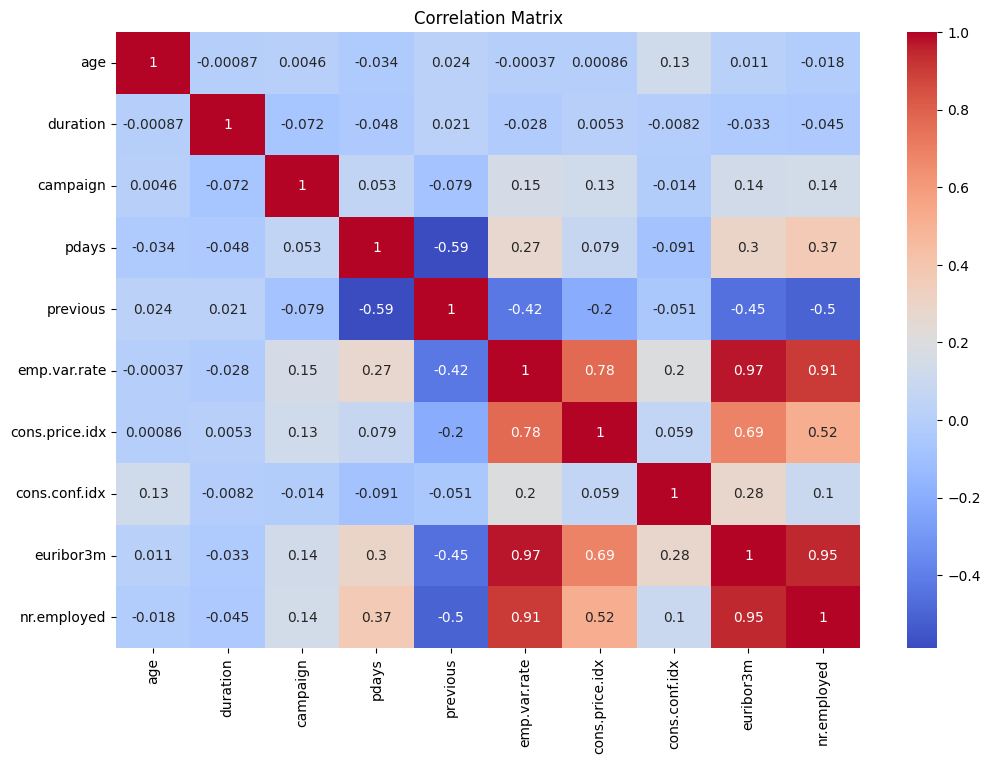

In [10]:
# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

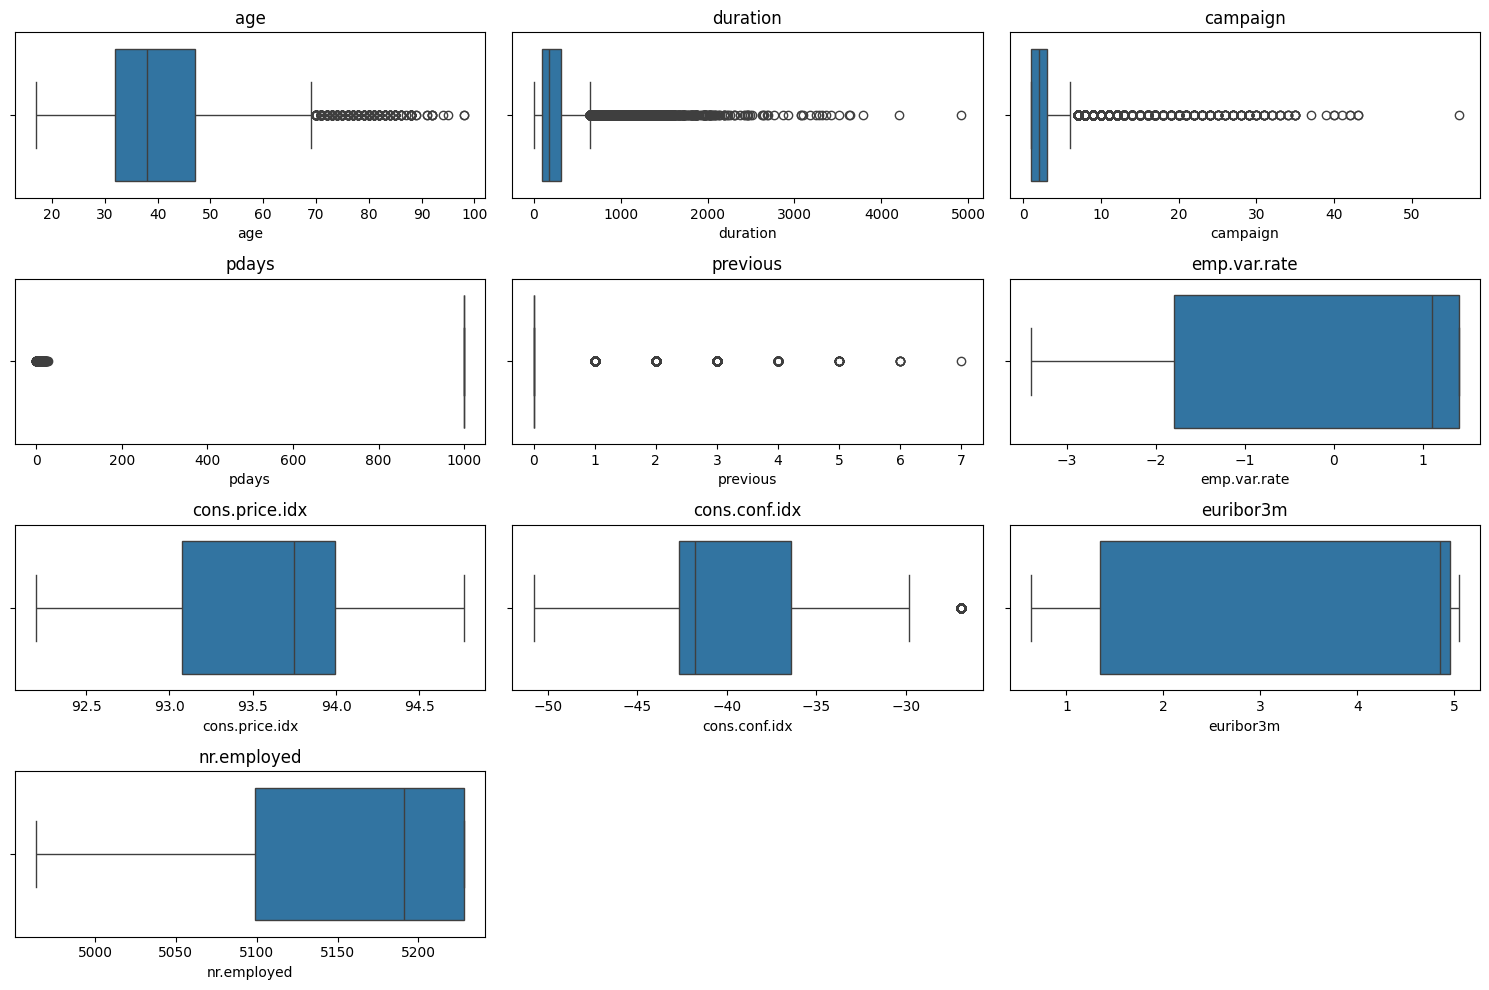

In [11]:
#Check Outliers (using Boxplots)
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_features):
    plt.subplot(4,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
#Categorical Counts
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      9

In [13]:
# Checking if there is unknown values
for col in categorical_features:
    print(f"{col}: {(df[col] == 'unknown').sum()} unknown values")

job: 330 unknown values
marital: 80 unknown values
education: 1731 unknown values
default: 8597 unknown values
housing: 990 unknown values
loan: 990 unknown values
contact: 0 unknown values
month: 0 unknown values
day_of_week: 0 unknown values
poutcome: 0 unknown values
y: 0 unknown values


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [17]:
# Make a copy to preserve original dataset
df_prepared = df.copy()

# 1️⃣ Drop target column 'y'
# We are performing UNSUPERVISED learning (clustering),
# so we must not use the label for training.
df_prepared = df_prepared.drop(columns=['y'])

# 2️⃣ Drop 'duration'
# Duration strongly leaks the outcome (long calls → likely subscription).
# It is not known before the call, so we remove it for realistic modeling.
df_prepared = df_prepared.drop(columns=['duration'])

print("Remaining shape:", df_prepared.shape)

Remaining shape: (41188, 19)


In [18]:
# Identify categorical columns
categorical_features = df_prepared.select_dtypes(include=['object']).columns

# Convert categorical variables into numeric using One-Hot Encoding
# K-Means requires purely numeric input.
# We use drop_first=True to avoid redundant dummy variables.
df_prepared = pd.get_dummies(df_prepared,
                             columns=categorical_features,
                             drop_first=True)

print("Shape after encoding:", df_prepared.shape)

# used one hot because: no artificial ordering is introduced

Shape after encoding: (41188, 52)


In [19]:
from sklearn.preprocessing import StandardScaler

# K-Means is distance-based.
# Features with larger scales (e.g., nr.employed) would dominate distance.
# Therefore, we standardize all features.

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_prepared)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(df_scaled, columns=df_prepared.columns)

df_scaled.head()

# Why StandardScaler: Centers data (mean = 0), Scales to unit variance, Prevents large-scale variables from dominating clustering

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
1,1.628993,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
2,-0.290186,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
3,-0.002309,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
4,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857


In [20]:
# Check for missing values
print("Missing values:", df_scaled.isnull().sum().sum())

# Check that all features are numeric
print("All numeric:", all(df_scaled.dtypes != 'object'))

print("Final dataset shape:", df_scaled.shape)

Missing values: 0
All numeric: True
Final dataset shape: (41188, 52)


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [21]:
from sklearn.cluster import KMeans

# We start with K = 3 as a reasonable initial assumption.
# In real analysis, K is usually validated using methods like Elbow or Silhouette.
K = 3

print("Initial number of clusters:", K)

Initial number of clusters: 3


In [22]:
# Initialize K-Means model
# random_state ensures reproducibility
# n_init=10 runs the algorithm multiple times and keeps the best solution

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# Fit model to scaled dataset
kmeans.fit(df_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [23]:
# Assign each data point to a cluster
cluster_labels = kmeans.labels_

# Add cluster labels to dataset
df_clustered = df_scaled.copy()
df_clustered['Cluster'] = cluster_labels

df_clustered.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,Cluster
0,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857,2
1,1.628993,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857,2
2,-0.290186,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857,2
3,-0.002309,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857,2
4,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.538317,...,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857,2


In [24]:
# Check how many points are in each cluster
df_clustered['Cluster'].value_counts()

,count
Cluster,
2,24120
1,15548
0,1520


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

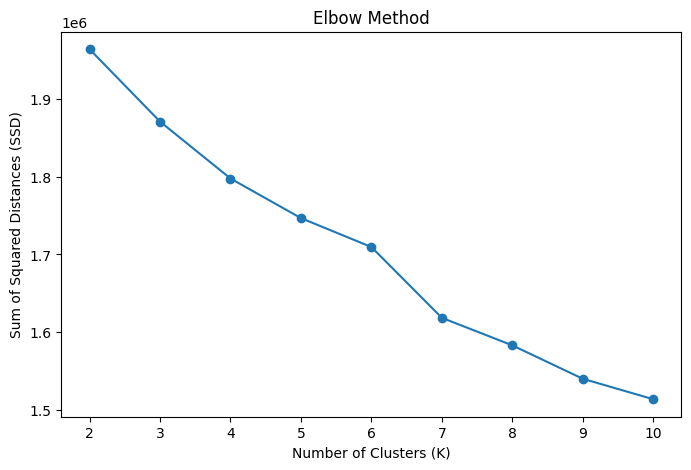

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute Sum of Squared Distances (SSD / Inertia) for different K values
ssd = []
K_range = range(2, 11)  # We start from 2 (silhouette not defined for K=1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    ssd.append(kmeans.inertia_)  # inertia_ = total within-cluster sum of squares

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.show()

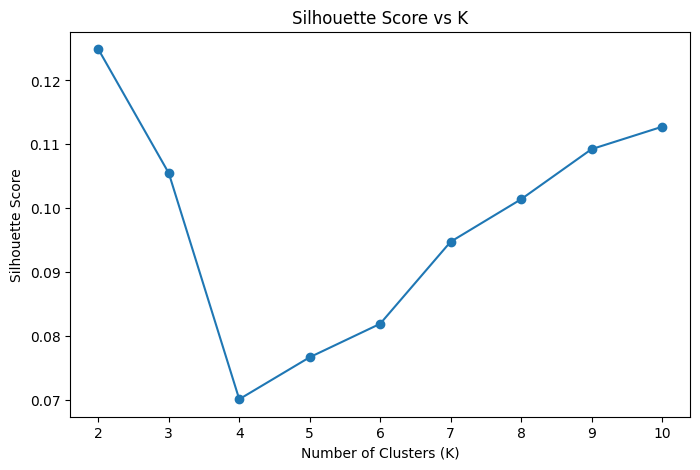

In [29]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

In [28]:

optimal_K = 7

kmeans_final = KMeans(n_clusters=optimal_K, random_state=42, n_init=10)
df_clustered['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("Final chosen K:", optimal_K)
df_clustered['Cluster'].value_counts()

Final chosen K: 7


,count
Cluster,
2,11835
4,11445
3,6549
0,5084
1,3801
6,1498
5,976
